In [4]:
!pip install -r requirements.txt

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ----------------- ---------------------- 4.2/9.3 MB 20.7 MB/s eta 0:00:01
   ---------------------------------- ----- 8.1/9.3 MB 20.0 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 15.2 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 17.8 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ------------------------ --------------- 4.5/7.2 MB 22.3 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 20.5 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 

In [5]:
import time
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [6]:
iris = load_iris(as_frame=True)

df = iris.frame
df["class"] = iris.target_names[iris.target]

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,class
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [7]:
X = df.drop(columns=["target", "class"])
y = df["class"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Target:
0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: class, dtype: str


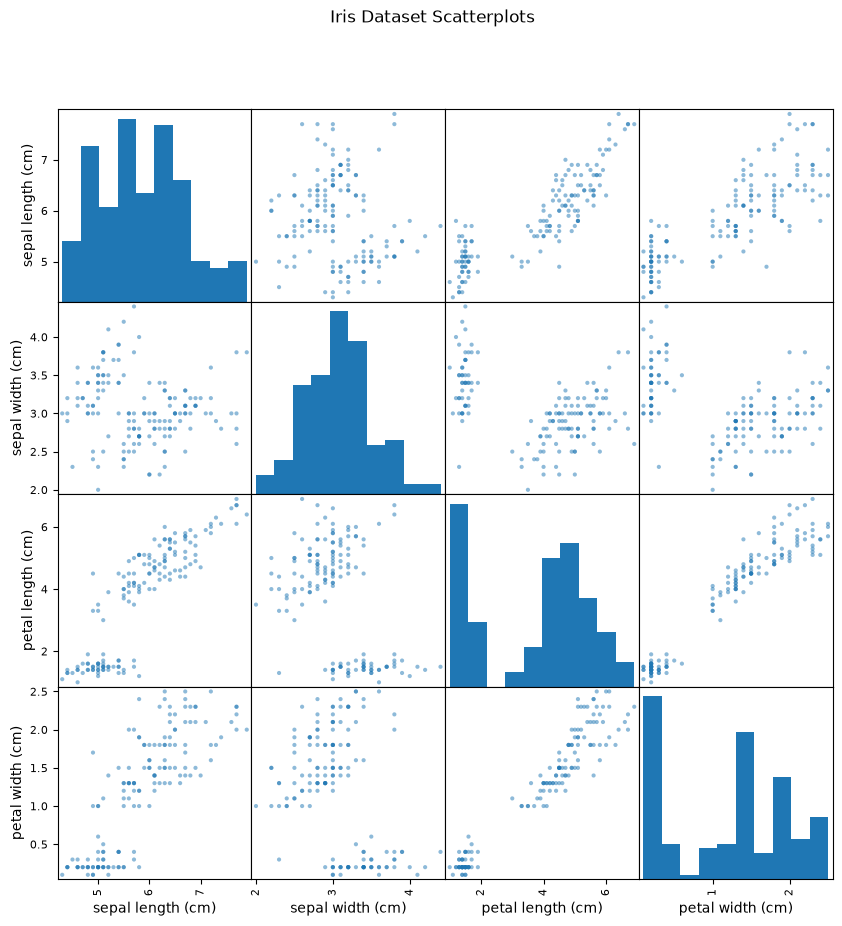

In [8]:
##scatterplot
pd.plotting.scatter_matrix(
    X,
    figsize=(10, 10),
    diagonal="hist"
)

plt.suptitle("Iris Dataset Scatterplots")
plt.show()

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 120
Test samples: 30


In [10]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

In [11]:
start_time = time.time()

pipeline.fit(X_train, y_train)

training_time = time.time() - start_time

print("Training Time:", training_time, "seconds")

Training Time: 0.20193815231323242 seconds


In [12]:
start_time = time.time()

y_pred = pipeline.predict(X_test)

testing_time = time.time() - start_time

print("Testing Time:", testing_time, "seconds")

Testing Time: 0.0025429725646972656 seconds


In [13]:
accuracy = accuracy_score(y_test, y_pred)

print("Test Prediction Accuracy:", accuracy)
print("Test Prediction Accuracy:", accuracy * 100, "%")

Test Prediction Accuracy: 1.0
Test Prediction Accuracy: 100.0 %


In [14]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


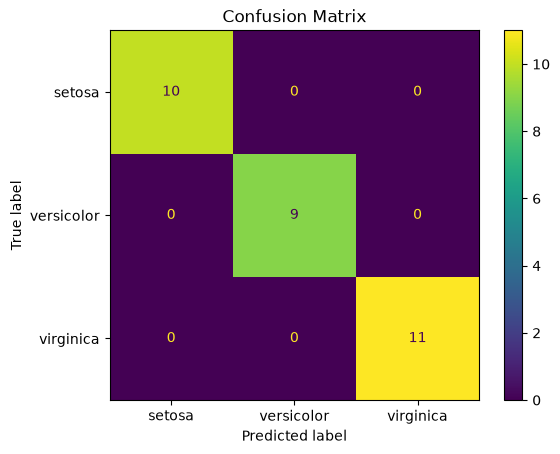

In [15]:
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
).plot()

plt.title("Confusion Matrix")
plt.show()